[*********************100%***********************]  1 of 1 completed
<ipython-input-14-bcb3ee7e6729>:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_returns = data.pct_change().fillna(method='ffill')


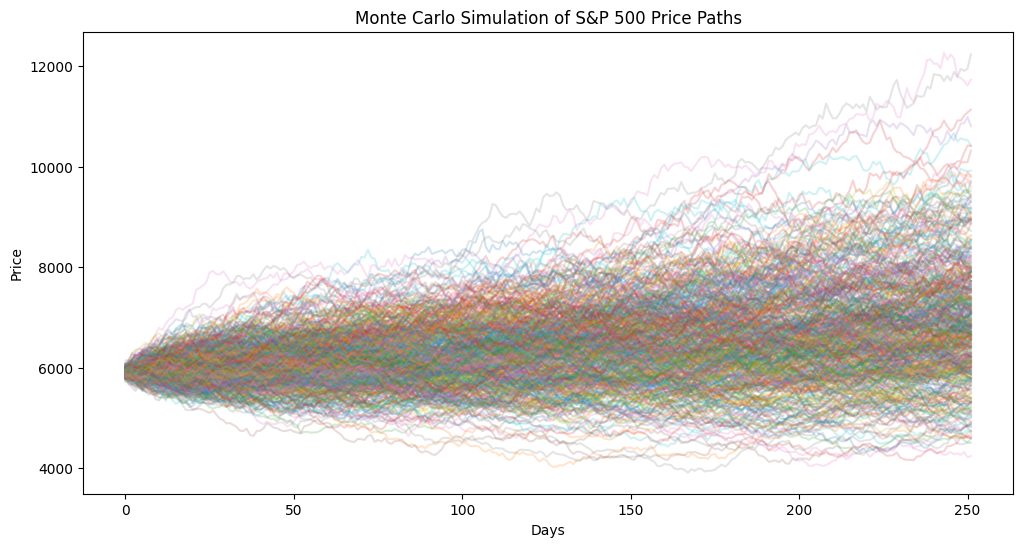

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ticker = "^GSPC"  # S&P 500 ticker
data = yf.download(ticker, start="2010-01-01", end="2024-11-21")['Adj Close']
daily_returns = data.pct_change().fillna(method='ffill')

mu = daily_returns.mean()  # Mean daily return
sigma = daily_returns.std()  # Standard deviation of daily return

# Parameters
n_simulations = 500  # Number of simulations
n_days = 252  # Number of trading days in a year (e.g., simulate 1 year)

simulations = np.zeros((n_days, n_simulations))

S0 = data.values[-1]

# Simulate price paths
for i in range(n_simulations):
    random_returns = np.random.normal(mu, sigma, n_days)
    price_path = S0 * np.exp(np.cumsum(random_returns))  # Geometric Brownian Motion
    simulations[:, i] = price_path


np.random.seed(42)
T = 1.0
dt = T / n
t = np.linspace(0, T, n)

mean = 0.1
std_dev = 0.2

paths = np.zeros((num_paths, n))
paths[:, 0] = 100

for i in range(num_paths):
    for j in range(1, n):
        dW = np.random.randn() * np.sqrt(dt)
        paths[i, j] = paths[i, j-1] * np.exp((mean - 0.5 * std_dev**2) * dt + std_dev * dW)

# Step 5: Visualize the results
plt.figure(figsize=(12, 6))
plt.plot(simulations, alpha=0.2)  # Plot all simulated paths with low opacity
plt.title("Monte Carlo Simulation of S&P 500 Price Paths")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()


In [ ]:
# Import libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define a class for the Monte Carlo simulation
class MonteCarloSimulator:
    def __init__(self, ticker, start_date, end_date, num_simulations, num_days):
        """
        Initialize the simulator with key parameters.

        :param ticker: Stock ticker (e.g., "^GSPC" for S&P 500)
        :param start_date: Start date for historical data (e.g., "2022-01-01")
        :param end_date: End date for historical data (e.g., "2023-01-01")
        :param num_simulations: Number of Monte Carlo simulations
        :param num_days: Number of days to simulate
        """
        self.ticker = ticker
        self.start_date = start_date
        self.end_date = end_date
        self.num_simulations = num_simulations
        self.num_days = num_days
        self.data = None
        self.daily_mean = None
        self.daily_std = None

    def fetch_data(self):
        """Fetch historical stock data from Yahoo Finance."""
        self.data = yf.download(self.ticker, start=self.start_date, end=self.end_date)['Close'].dropna()
        if self.data.empty:
            raise ValueError("No data fetched. Check the ticker and date range.")

    def calculate_daily_statistics(self):
        """Calculate the daily mean and standard deviation of returns."""
        daily_returns = self.data.pct_change().dropna()
        self.daily_mean = daily_returns.mean()
        self.daily_std = daily_returns.std()

    def simulate_paths(self):
        """Perform Monte Carlo simulation."""
        if self.daily_mean is None or self.daily_std is None:
            raise ValueError("Daily statistics not calculated. Call calculate_daily_statistics() first.")

        # Change here: Get the last price as a scalar value instead of a Series
        last_price = self.data.values.iloc[-1]

        simulations = np.zeros((self.num_days, self.num_simulations))

        for i in range(self.num_simulations):
            random_returns = np.random.normal(self.daily_mean, self.daily_std, self.num_days)
            # Now 'last_price' is a scalar, so this multiplication will work correctly
            price_path = last_price * np.exp(np.cumsum(random_returns))
            simulations[:, i] = price_path

        return simulations

    def plot_simulations(self, simulations):
        """Plot the simulated price paths."""
        plt.figure(figsize=(12, 6))
        plt.plot(simulations, alpha=0.2)
        plt.title(f"Monte Carlo Simulation of {self.ticker} Price Paths")
        plt.xlabel("Days")
        plt.ylabel("Price")
        plt.show()


# Initialize and run the simulator
if __name__ == "__main__":
    # Parameters
    ticker = "^GSPC"  # S&P 500 index
    start_date = "2022-01-01"  # Last year's start date
    end_date = "2023-01-01"  # Last year's end date
    num_simulations = 500  # Number of Monte Carlo paths
    num_days = 252  # Number of trading days in a year

    # Create an instance of the simulator
    simulator = MonteCarloSimulator(ticker, start_date, end_date, num_simulations, num_days)

    # Fetch data and calculate statistics
    simulator.fetch_data()
    simulator.calculate_daily_statistics()

    # Perform the simulation
    simulations = simulator.simulate_paths()

    # Plot the results
    simulator.plot_simulations(simulations)


[*********************100%***********************]  1 of 1 completed


AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [ ]:
class MonteCarloSimulator:
    # ... (other methods remain the same)

    def simulate_paths(self):
        """Perform Monte Carlo simulation."""
        if self.daily_mean is None or self.daily_std is None:
            raise ValueError("Daily statistics not calculated. Call calculate_daily_statistics() first.")

        # Change here: Get the last price as a scalar value instead of a Series
        last_price = self.data.iloc[-1]

        simulations = np.zeros((self.num_days, self.num_simulations))

        for i in range(self.num_simulations):
            random_returns = np.random.normal(self.daily_mean, self.daily_std, self.num_days)
            # Now 'last_price' is a scalar, so this multiplication will work correctly
            price_path = last_price * np.exp(np.cumsum(random_returns))
            simulations[:, i] = price_path

        return simulations

In [ ]:
class MonteCarloSimulator:
    # ... (other methods remain the same)

    def simulate_paths(self):
        """Perform Monte Carlo simulation."""
        if self.daily_mean is None or self.daily_std is None:
            raise ValueError("Daily statistics not calculated. Call calculate_daily_statistics() first.")

        # Change here: Get the last price as a scalar value instead of a Series
        last_price = self.data.iloc[-1]

        simulations = np.zeros((self.num_days, self.num_simulations))

        for i in range(self.num_simulations):
            random_returns = np.random.normal(self.daily_mean, self.daily_std, self.num_days)
            # Now 'last_price' is a scalar, so this multiplication will work correctly
            price_path = last_price * np.exp(np.cumsum(random_returns))
            simulations[:, i] = price_path

        return simulations

[*********************100%***********************]  1 of 1 completed
<ipython-input-17-d07c65b06d59>:33: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  last_price = float(self.data.iloc[-1])


daily mean = -0.000890, daily std = 0.015263


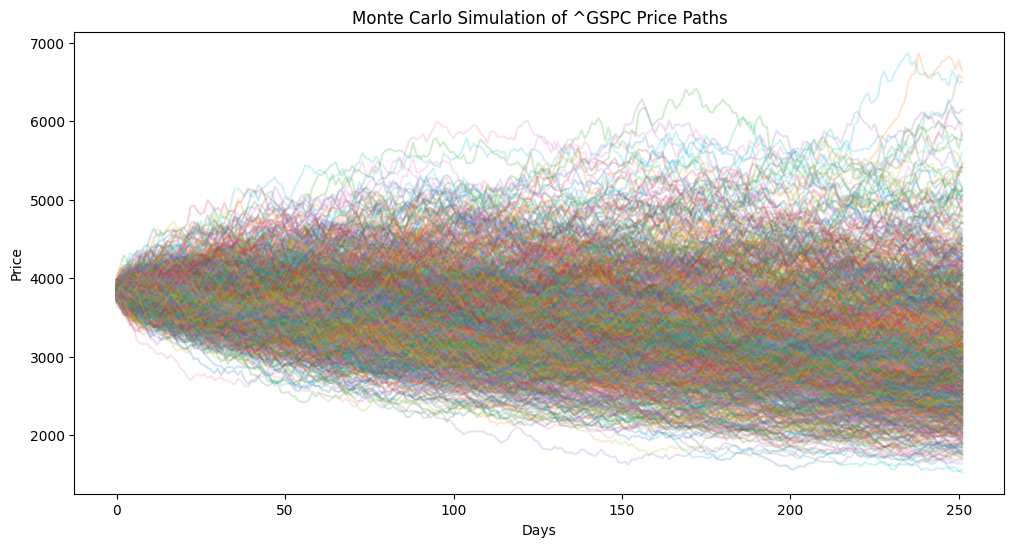

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class MonteCarloSimulator:
    def __init__(self, ticker, start_date, end_date, num_simulations, num_days):
        self.ticker = ticker
        self.start_date = start_date
        self.end_date = end_date
        self.num_simulations = num_simulations
        self.num_days = num_days
        self.data = None
        self.daily_mean = None
        self.daily_std = None

    def fetch_data(self):
        self.data = yf.download(self.ticker, start=self.start_date, end=self.end_date)['Adj Close'].dropna()
        if self.data.empty:
            raise ValueError("Empty data")

    def calculate_daily_statistics(self):
        daily_returns = np.log(self.data / self.data.shift(1)).dropna()
        self.daily_mean = daily_returns.mean()
        self.daily_std = daily_returns.std()

        return self.daily_mean, self.daily_std

    def simulate_paths(self):
        if self.daily_mean is None or self.daily_std is None:
            raise ValueError("Daily statistics don't be calculated.")

        last_price = float(self.data.iloc[-1])
        simulations = np.zeros((self.num_days, self.num_simulations))

        for i in range(self.num_simulations):
            random_returns = np.random.normal(self.daily_mean, self.daily_std, self.num_days)
            price_path = last_price * np.exp(np.cumsum(random_returns))
            simulations[:, i] = price_path

        return simulations

    def plot_simulations(self, simulations):
        plt.figure(figsize=(12, 6))
        plt.plot(simulations, alpha=0.2)
        plt.title(f"Monte Carlo Simulation of {self.ticker} Price Paths")
        plt.xlabel("Days")
        plt.ylabel("Price")
        plt.show()

if __name__ == "__main__":
    ticker = "^GSPC"
    start_date = "2022-01-01"
    end_date = "2023-01-01"
    num_simulations = 1000
    num_days = 252

    simulator = MonteCarloSimulator(ticker, start_date, end_date, num_simulations, num_days)

    simulator.fetch_data()
    daily_mean,daily_std = simulator.calculate_daily_statistics()
    print(f"daily mean = {daily_mean.iloc[0]:.6f}, daily std = {daily_std.iloc[0]:.6f}")
    simulations = simulator.simulate_paths()
    simulator.plot_simulations(simulations)

In [ ]:
# 找1000以內的質數
def find_prime(n):
    prime = []
    for i in range(2, n + 1):
        for j in range(2, i):
            if i % j == 0:
                break
        else:
            prime.append(i)
    return prime

n = 1000
print(f"{n}以內的所有質數:", find_prime(n))

[2,
 3,
 5,
 7,
 11,
 13,
 17,
 19,
 23,
 29,
 31,
 37,
 41,
 43,
 47,
 53,
 59,
 61,
 67,
 71,
 73,
 79,
 83,
 89,
 97,
 101,
 103,
 107,
 109,
 113,
 127,
 131,
 137,
 139,
 149,
 151,
 157,
 163,
 167,
 173,
 179,
 181,
 191,
 193,
 197,
 199,
 211,
 223,
 227,
 229,
 233,
 239,
 241,
 251,
 257,
 263,
 269,
 271,
 277,
 281,
 283,
 293,
 307,
 311,
 313,
 317,
 331,
 337,
 347,
 349,
 353,
 359,
 367,
 373,
 379,
 383,
 389,
 397,
 401,
 409,
 419,
 421,
 431,
 433,
 439,
 443,
 449,
 457,
 461,
 463,
 467,
 479,
 487,
 491,
 499,
 503,
 509,
 521,
 523,
 541,
 547,
 557,
 563,
 569,
 571,
 577,
 587,
 593,
 599,
 601,
 607,
 613,
 617,
 619,
 631,
 641,
 643,
 647,
 653,
 659,
 661,
 673,
 677,
 683,
 691,
 701,
 709,
 719,
 727,
 733,
 739,
 743,
 751,
 757,
 761,
 769,
 773,
 787,
 797,
 809,
 811,
 821,
 823,
 827,
 829,
 839,
 853,
 857,
 859,
 863,
 877,
 881,
 883,
 887,
 907,
 911,
 919,
 929,
 937,
 941,
 947,
 953,
 967,
 971,
 977,
 983,
 991,
 997]

In [ ]:
# 費波那契數列
def fibonacci_sequence(n):
    fib_sequence = [0, 1]
    while len(fib_sequence) < n:
        next_number = fib_sequence[-1] + fib_sequence[-2]
        fib_sequence.append(next_number)
    return fib_sequence

def golden_ratio(n):
    golden_ratio_errar = 1
    m = 3
    while golden_ratio_errar > n:
      fib_sequence = fibonacci_sequence(m)
      golden_ratio = (fib_sequence[-2] / fib_sequence[-1])
      golden_ratio_errar = abs((fib_sequence[-3] / fib_sequence[-2]) - golden_ratio)
      m += 1
    return golden_ratio

n = 10
print(f"{n}位費波那契數列:", fibonacci_sequence(n))
error = 0.000001
print("黃金比例趨近值:", golden_ratio(error))

10位費波那契數列: [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]
黃金比例趨近值: 0.6180338134001252
